In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


In [18]:
# 5_1_acoustic_descriptive
df = pd.read_csv("../outputs/analysis/tables/5_1_acoustic_descriptive.csv")
print("5_1_acoustic_descriptive")
print(f"shape: {df.shape}")
print(df.head(10))
print("\naggregated by phoneme (mean of CV)")
print(df.groupby("phoneme")["cv_hz"].mean().sort_values(ascending=False))

# Q2: 
# 5_1_variance_decomposition
vd = pd.read_csv("../outputs/analysis/tables/5_1_variance_decomposition.csv")
print("\n5_1_variance_decomposition")
vd = (vd[["phoneme", "prop_inter", "prop_intra", "prop_resid", "n_tokens"]]
         .sort_values("prop_inter", ascending=False))
print("=== Q2: Variance decomposition of F1 (Lobanov), per phoneme ===")
print(vd.to_string(index=False))

# comparing with neural
lme = pd.read_csv("../outputs/analysis/tables/7_lme_results.csv")

icc_null = lme[(lme["model"] == "null_model") & lme["icc"].notna()].copy()

def parse_tag(tag):
    parts = str(tag).split("_")
    if len(parts) < 2:
        return None, None, None
    phoneme = parts[-1]
    if "acoustic" in tag:
        if phoneme == "all":
            return "acoustic", parts[1], "all"
        return "acoustic", parts[1], phoneme
    if "whisper_l28" in tag:
        return "whisper_l28", "_".join(parts[2:-1]), phoneme
    if "whisper_l8" in tag:
        return "whisper_l8", "_".join(parts[2:-1]), phoneme
    if "xlsr" in tag:
        return f"xlsr_l{parts[1][1:]}", "_".join(parts[2:-1]), phoneme
    return None, None, None

icc_null[["representation", "feature", "phoneme"]] = icc_null["tag"].apply(
    lambda t: pd.Series(parse_tag(t))
)

ac_icc = (icc_null[(icc_null["representation"] == "acoustic")
                   & (icc_null["feature"] == "F1")
                   & (icc_null["phoneme"] != "all")]
          [["phoneme", "icc"]]
          .rename(columns={"icc": "icc_acoustic_F1"}))

neural_icc = icc_null[
    (icc_null["feature"] == "pc_0") & (icc_null["phoneme"] != "all")
].copy()

neural_pivot = (neural_icc.pivot_table(index="phoneme",
                                       columns="representation",
                                       values="icc")
                .add_prefix("icc_"))


combined = ac_icc.merge(neural_pivot, on="phoneme", how="outer")
combined = combined.sort_values("icc_acoustic_F1", ascending=False)
neural_cols = ["icc_whisper_l28", "icc_whisper_l8",
               "icc_xlsr_l4", "icc_xlsr_l12", "icc_xlsr_l20"]

ranked = combined.sort_values("icc_whisper_l28", ascending=False)
print(ranked[["phoneme"] + neural_cols].to_string(index=False))

5_1_acoustic_descriptive
shape: (80, 11)
   Unnamed: 0 phoneme l1_status gender     feature     n      mean    median  \
0           0       a        L1      f  F1_mid_lob   255  0.950496  0.997795   
1           1       a        L1      f  F2_mid_lob   255 -0.437999 -0.832521   
2           2       a        L1      m  F1_mid_lob   865  0.802874  0.726869   
3           3       a        L1      m  F2_mid_lob   865 -0.384206 -0.599827   
4           4       a        L2      f  F1_mid_lob  1272  0.775751  0.852812   
5           5       a        L2      f  F2_mid_lob  1272 -0.510027 -0.615893   
6           6       a        L2      m  F1_mid_lob   253  0.942720  0.982379   
7           7       a        L2      m  F2_mid_lob   253 -0.453767 -0.539811   
8           8       e        L1      f  F1_mid_lob    24 -0.384350 -0.631612   
9           9       e        L1      f  F2_mid_lob    24  0.813287  0.798400   

        std       iqr     cv_hz  
0  0.720002  0.796600  0.141723  
1  0.70786

In [21]:
# Q3
ns = pd.read_csv("../outputs/analysis/tables/5_2_neural_class_separation.csv")

# Order layers from low to high
order = ["whisper_l8", "whisper_l28", "xlsr_l4", "xlsr_l12", "xlsr_l20"]
ns["layer"] = pd.Categorical(ns["layer"], categories=order, ordered=True)

ns_q3 = (ns[["layer", "dr", "between_class_var_ratio", "cosine_ratio"]]
         .sort_values(["layer", "dr"]))
print("Phoneme separation in neural representations")
print(ns_q3.query("dr=='UMAP'"))

Phoneme separation in neural representations
         layer    dr  between_class_var_ratio  cosine_ratio
3   whisper_l8  UMAP                 0.314696      1.188141
1  whisper_l28  UMAP                 0.655434      2.083176
9      xlsr_l4  UMAP                 0.323606      1.046542
5     xlsr_l12  UMAP                 0.507616      2.988226
7     xlsr_l20  UMAP                 0.668462     39.899635


In [23]:
# Q4
mr = pd.read_csv("../outputs/analysis/tables/5_3_mantel_rsm.csv")

# Acoustic vs neural
ac_vs_neural = mr[mr["comparison"].str.startswith("acoustic vs")]
print("Acoustic RSM vs neural RSMs")
print(ac_vs_neural[["comparison", "mantel_r", "mantel_p"]].to_string(index=False))

# Neural vs neural
neural_vs_neural = mr[~mr["comparison"].str.startswith("acoustic vs")]
print("\nNeural RSMs pairwise")
print(neural_vs_neural[["comparison", "mantel_r", "mantel_p"]].to_string(index=False))

Acoustic RSM vs neural RSMs
             comparison  mantel_r  mantel_p
acoustic vs whisper_l28  0.671542    0.0004
 acoustic vs whisper_l8  0.740316    0.0002
   acoustic vs xlsr_l12  0.709223    0.0002
   acoustic vs xlsr_l20  0.662846    0.0002
    acoustic vs xlsr_l4  0.688801    0.0002

Neural RSMs pairwise
               comparison  mantel_r  mantel_p
whisper_l28 vs whisper_l8  0.843874    0.0002
  whisper_l28 vs xlsr_l12  0.846772    0.0002
  whisper_l28 vs xlsr_l20  0.824901    0.0002
   whisper_l28 vs xlsr_l4  0.820817    0.0002
   whisper_l8 vs xlsr_l12  0.980632    0.0002
   whisper_l8 vs xlsr_l20  0.971410    0.0002
    whisper_l8 vs xlsr_l4  0.978524    0.0002
     xlsr_l12 vs xlsr_l20  0.973518    0.0002
      xlsr_l12 vs xlsr_l4  0.981818    0.0002
      xlsr_l20 vs xlsr_l4  0.987088    0.0002


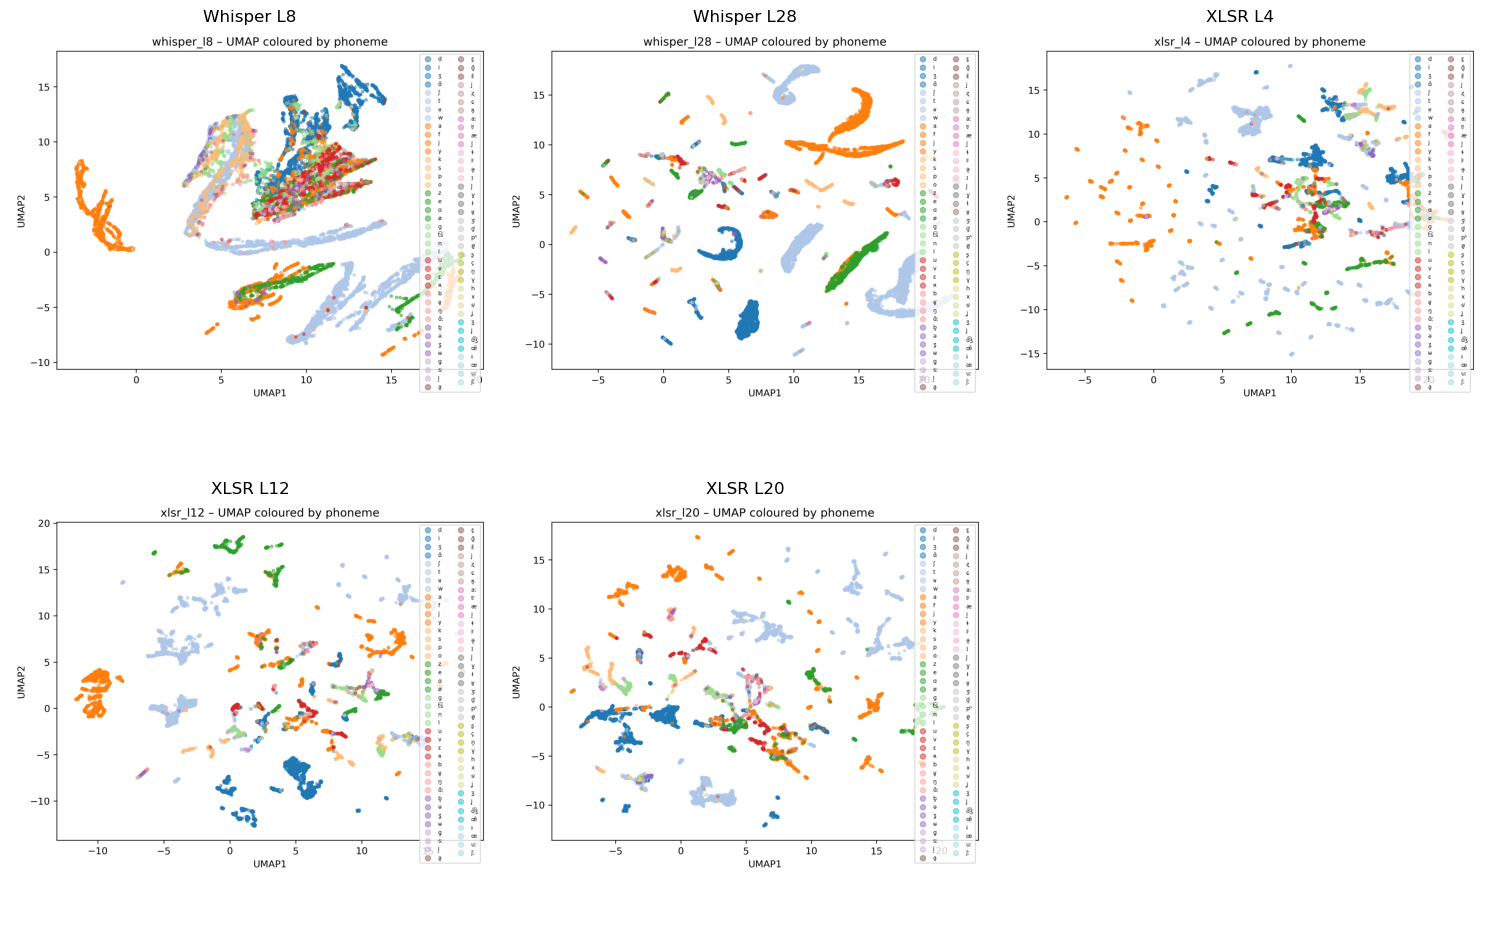

In [ ]:
imgs = [
    Image.open("../outputs/analysis/figures/5_2_neural_whisper_l8_UMAP_phoneme.png"),
    Image.open("../outputs/analysis/figures/5_2_neural_whisper_l28_UMAP_phoneme.png"),
    Image.open("../outputs/analysis/figures/5_2_neural_xlsr_l4_UMAP_phoneme.png"),
    Image.open("../outputs/analysis/figures/5_2_neural_xlsr_l12_UMAP_phoneme.png"),
    Image.open("../outputs/analysis/figures/5_2_neural_xlsr_l20_UMAP_phoneme.png"),
]

titles = ["Whisper L8", "Whisper L28", "XLSR L4", "XLSR L12", "XLSR L20"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # transforme en liste simple

for i, ax in enumerate(axes):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
models = [
    ("whisper", "l8",  "Whisper L8"),
    ("whisper", "l28", "Whisper L28"),
    ("xlsr", "l4",     "XLSR L4"),
    ("xlsr", "l12",    "XLSR L12"),
    ("xlsr", "l20",    "XLSR L20"),
]

colorings = ["phoneme", "l1_status", "gender"]

projection_methods = ["UMAP", "PCA"]

path = Path("../outputs/analysis/figures")

for proj in projection_methods:

    fig, axes = plt.subplots(
        nrows=len(models),
        ncols=len(colorings),
        figsize=(15, 22)
    )

    for row, (model, layer, title) in enumerate(models):

        for col, coloring in enumerate(colorings):

            filename = (
                f"5_2_neural_{model}_{layer}_{proj}_{coloring}.png"
            )

            img_path = path / filename

            ax = axes[row, col]

            if img_path.exists():
                img = Image.open(img_path)
                ax.imshow(img)

            ax.axis("off")

            if row == 0:
                ax.set_title(coloring.replace("_", " ").title(), fontsize=14)

            if col == 0:
                ax.set_ylabel(title, fontsize=14)

    fig.suptitle(f"{proj} projections", fontsize=20)

    plt.tight_layout()
    plt.show()

In [43]:

df = pd.read_csv("../outputs/analysis/tables/6_2_mcnemar.csv")
df.iloc[:, 1:]


,pair,n_matched,acc_1,acc_2,discordant_1_only,discordant_2_only,statistic,p_value
0,acoustic vs whisper_l28,6871,0.691457,0.799447,780,1522,238.523458,8.253947e-54
1,acoustic vs whisper_l8,6871,0.691457,0.779071,704,1306,179.701990,5.629739e-41
2,acoustic vs xlsr_l12,6871,0.691457,0.785475,749,1395,194.041511,4.170652e-44
3,acoustic vs xlsr_l20,6871,0.691457,0.813710,561,1401,358.777268,5.197944e-80
4,acoustic vs xlsr_l4,6871,0.691457,0.809344,539,1349,346.653072,2.269815e-77
5,whisper_l28 vs whisper_l8,6871,0.799447,0.779071,651,511,16.627367,4.548989e-05
6,whisper_l28 vs xlsr_l12,6871,0.799447,0.785475,341,245,15.401024,8.694117e-05
7,whisper_l28 vs xlsr_l20,6871,0.799447,0.813710,393,491,10.643665,1.104486e-03
8,whisper_l28 vs xlsr_l4,6871,0.799447,0.809344,416,484,4.987778,2.552697e-02
9,whisper_l8 vs xlsr_l12,6871,0.779071,0.785475,397,441,2.206444,1.374352e-01


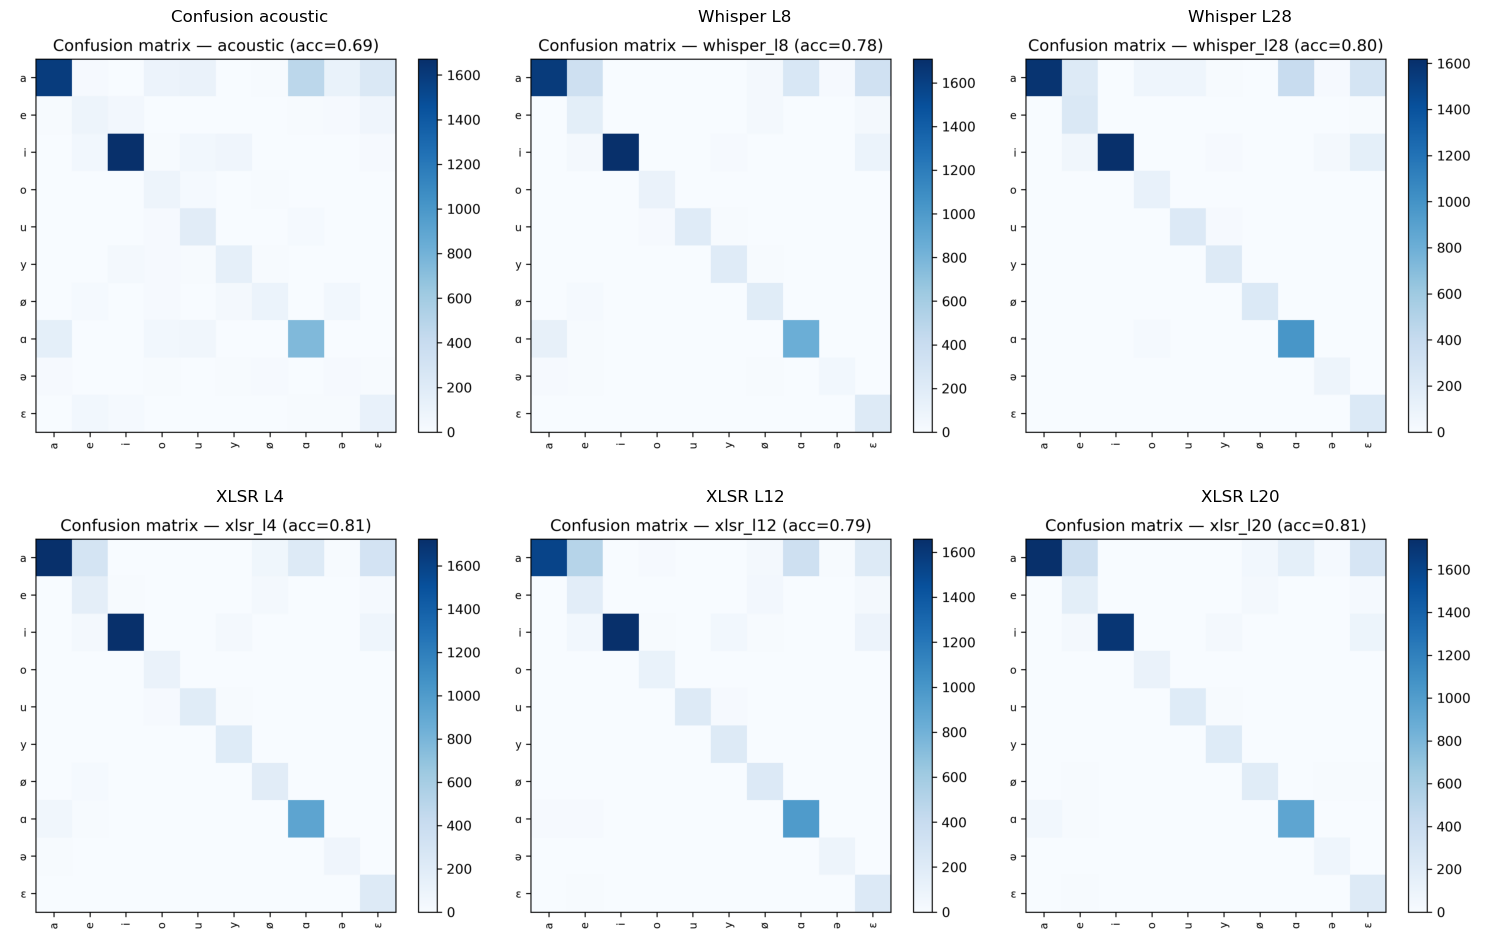

In [ ]:
imgs = [
    Image.open("../outputs/analysis/figures/6_2_confusion_acoustic.png"),
    Image.open("../outputs/analysis/figures/6_2_confusion_whisper_l8.png"),
    Image.open("../outputs/analysis/figures/6_2_confusion_whisper_l28.png"),
    Image.open("../outputs/analysis/figures/6_2_confusion_xlsr_l4.png"),
    Image.open("../outputs/analysis/figures/6_2_confusion_xlsr_l12.png"),
    Image.open("../outputs/analysis/figures/6_2_confusion_xlsr_l20.png")
]

titles = ["Confusion acoustic", "Whisper L8", "Whisper L28","XLSR L4", "XLSR L12", "XLSR L20"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # transforme en liste simple

for i, ax in enumerate(axes):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

# LME Analysis

In [ ]:
lme = pd.read_csv("../outputs/analysis/tables/7_lme_results.csv")


def parse_tag(tag):
    parts = str(tag).split("_")
    if len(parts) < 2:
        return None, None, None
    phoneme = parts[-1]
    if "acoustic" in tag:
        return "acoustic", parts[1], phoneme
    if "whisper_l28" in tag:
        return "whisper_l28", "_".join(parts[2:-1]), phoneme
    if "whisper_l8" in tag:
        return "whisper_l8", "_".join(parts[2:-1]), phoneme
    if "xlsr_l4" in tag:
        return "xlsr_l4", "_".join(parts[2:-1]), phoneme
    if "xlsr_l12" in tag:
        return "xlsr_l12", "_".join(parts[2:-1]), phoneme
    if "xlsr_l20" in tag:
        return "xlsr_l20", "_".join(parts[2:-1]), phoneme
    return None, None, None

lme[["rep", "feature", "phoneme"]] = lme["tag"].apply(
    lambda t: pd.Series(parse_tag(t))
)


In [91]:
icc_a = lme[
    (lme["model"] == "null_model")
    & lme["icc"].notna()
    & (lme["phoneme"] == "a")
].copy()

# Acoustic F1 + F2 + 5 PCs whisper_l28
mask = (
    ((icc_a["rep"] == "acoustic") & (icc_a["feature"].isin(["F1", "F2"])))
    | ((icc_a["rep"] == "whisper_l28") & (icc_a["feature"].str.startswith("pc_")))
)
target = icc_a[mask][["rep", "feature", "icc"]].sort_values(["rep", "feature"])


# Mean of 5 PCs
wh_icc_mean = icc_a[
    (icc_a["rep"] == "whisper_l28") & (icc_a["feature"].str.startswith("pc_"))
]["icc"].mean()
print(f"\nMean ICC whisper_l28 PC0-4 for /a/: {wh_icc_mean:.4f}")
target


Mean ICC whisper_l28 PC0-4 for /a/: 0.0455


,rep,feature,icc
0,acoustic,F1,0.297023
6,acoustic,F2,0.116508
132,whisper_l28,pc_0,0.065991
138,whisper_l28,pc_1,0.014649
144,whisper_l28,pc_2,0.051844
150,whisper_l28,pc_3,0.086927
156,whisper_l28,pc_4,0.008317


In [79]:
inter = lme[lme["model"] == "full_interaction_coef"].copy()

ac_inter = inter[
    (inter["rep"] == "acoustic")
    & (inter["feature"].isin(["F1", "F2"]))
    & (inter["phoneme"] != "all")
][["phoneme", "feature", "coef", "p", "ci_lo", "ci_hi"]]
print("=== Acoustic interaction (F1, F2 per phoneme) ===")
ac_inter

=== Acoustic interaction (F1, F2 per phoneme) ===


,phoneme,feature,coef,p,ci_lo,ci_hi
3,a,F1,35.670393,0.634989,-111.602127,182.942913
9,a,F2,-97.232009,0.081710,-206.702141,12.238123
15,e,F1,-7.289760,0.839627,-77.891150,63.311630
21,e,F2,332.042149,0.013101,69.734681,594.349617
27,i,F1,83.706757,0.052577,-0.932218,168.345733
33,i,F2,127.572409,0.272950,-100.502794,355.647612
39,o,F1,38.009851,0.353664,-42.310902,118.330605
45,o,F2,-406.350736,0.002340,-668.051251,-144.650222
51,u,F1,5.976248,0.876651,-69.487651,81.440147
57,u,F2,-226.380774,0.056891,-459.397295,6.635748


In [ ]:
wh_inter = inter[
    (inter["rep"] == "whisper_l28")
    & (inter["feature"].str.startswith("pc_"))
    & (inter["phoneme"] != "all")
][["phoneme", "feature", "coef", "p"]]
print("\n=== Whisper_l28 interaction (PC0-4 per phoneme) ===")
wh_inter

In [ ]:
ac_sig = (ac_inter["p"] < 0.05).sum()
wh_sig = (wh_inter["p"] < 0.05).sum()
print("\nNumber of significant (p<0.05):")
print(f"  Acoustic (F1+F2 x 10 phonemes = 20 contrasts): {ac_sig}/{len(ac_inter)}")
print(f"  Whisper_l28 (5 PCs x 10 phonemes = 50 contrasts): {wh_sig}/{len(wh_inter)}")


Number of significant (p<0.05):
  Acoustic (F1+F2 x 10 phonemes = 20 contrasts): 5/20
  Whisper_l28 (5 PCs x 10 phonemes = 50 contrasts): 0/50


In [58]:
# Whisper l28 PC0 only
wh_inter = inter[inter["tag"].str.startswith("whisper_l28_pc_0_")]
wh_inter

,tag,coef,p,ci_lo,ci_hi
135,whisper_l28_pc_0_a,0.000497,0.998473,-0.508446,0.509439
165,whisper_l28_pc_0_e,0.022621,0.903111,-0.341598,0.386841
195,whisper_l28_pc_0_i,-0.011667,0.944235,-0.338590,0.315255
225,whisper_l28_pc_0_o,0.108744,0.653970,-0.366731,0.584219
255,whisper_l28_pc_0_u,0.236016,0.239616,-0.157354,0.629386
285,whisper_l28_pc_0_y,0.038753,0.866517,-0.413124,0.490629
315,whisper_l28_pc_0_ø,0.106364,0.651649,-0.355392,0.568120
345,whisper_l28_pc_0_ɑ,0.482530,0.485479,-0.873338,1.838398
375,whisper_l28_pc_0_ə,-0.149527,0.741527,-1.038064,0.739009
405,whisper_l28_pc_0_ɛ,0.110962,0.588396,-0.290916,0.512839


In [89]:
r2 = lme[lme["model"] == "main"][["rep", "feature", "phoneme", "r2_marginal"]].copy()

mask = (
    (r2["feature"].isin(["F1", "F2"]))
    | (r2["feature"].str.startswith("pc_"))
)
r2 = r2[mask].dropna(subset=["r2_marginal"])

mean_per_rep = r2.groupby("rep")["r2_marginal"].mean().sort_values(ascending=False)
print("=== Mean marginal R² per representation (averaged over features and phonemes) ===")
print(mean_per_rep.to_string())

pivot = r2.groupby(["phoneme", "rep"])["r2_marginal"].mean().unstack("rep")
print("\n=== Mean R² per phoneme x representation (averaged over features) ===")
print(pivot.round(3).to_string())

=== Mean marginal R² per representation (averaged over features and phonemes) ===
rep
acoustic       0.204265
whisper_l8     0.159166
xlsr_l20       0.136281
whisper_l28    0.098713
xlsr_l4        0.083666
xlsr_l12       0.065349

=== Mean R² per phoneme x representation (averaged over features) ===
rep      acoustic  whisper_l28  whisper_l8  xlsr_l12  xlsr_l20  xlsr_l4
phoneme                                                                
a           0.107        0.011       0.118     0.020     0.068    0.037
all         0.068        0.007       0.074     0.006     0.051    0.014
e           0.207        0.089       0.204     0.055     0.109    0.085
i           0.255        0.014       0.070     0.034     0.092    0.035
o           0.305        0.254       0.230     0.045     0.237    0.118
u           0.088        0.049       0.099     0.029     0.120    0.034
y           0.162        0.117       0.198     0.049     0.090    0.056
ø           0.379        0.159       0.195     0.10

# CI / ROPE Analysis

In [119]:
from pathlib import Path
TABLES = Path("../outputs/analysis/tables")

ac = pd.read_csv(TABLES / "8_1_acoustic_ci_rope.csv")
print("=== Acoustic CI/ROPE ===")
print(f"shape: {ac.shape}")
print(f"contrasts: {ac['contrast'].unique()}")
print("rope_class counts:")
print(ac.groupby("contrast")["rope_class"].value_counts().to_string())
print()

print("\nL1 vs L2 main effect")
res = ac[ac["contrast"] == "L1_vs_L2"][["phoneme", "feature", "coef", "ci_lo", "ci_hi", "rope_class"]]
res

=== Acoustic CI/ROPE ===
shape: (34, 10)
contrasts: <StringArray>
['L1_vs_L2', 'L1xGender']
Length: 2, dtype: str
rope_class counts:
contrast   rope_class    
L1_vs_L2   indeterminate     17
           non-equivalent     3
L1xGender  indeterminate      8
           undetermined       5
           non-equivalent     1


L1 vs L2 main effect


,phoneme,feature,coef,ci_lo,ci_hi,rope_class
0,a,F1,-114.625129,-173.938823,-41.235041,non-equivalent
2,a,F2,-102.453596,-172.833300,-12.857369,indeterminate
4,e,F1,-55.719899,-90.734595,-16.916771,indeterminate
6,e,F2,-223.995357,-387.055341,-51.170635,non-equivalent
8,i,F1,-18.492489,-65.682026,36.263789,indeterminate
10,i,F2,-362.509752,-508.803085,-189.543249,non-equivalent
12,o,F1,-45.799258,-83.350978,-5.290605,indeterminate
14,o,F2,-146.968200,-294.658850,17.128268,indeterminate
16,u,F1,16.904863,-16.133340,47.975145,indeterminate
17,u,F2,-86.898717,-193.886696,17.970221,indeterminate


In [124]:
ne = pd.read_csv(TABLES / "8_2_neural_ci_rope.csv")

df = (ne.groupby("layer")["rope_class"]
           .value_counts()
           .unstack(fill_value=0)
           .reset_index())

for c in ["equivalent", "indeterminate", "non-equivalent"]:
    if c not in df.columns:
        df[c] = 0

df = df[["layer", "equivalent", "indeterminate", "non-equivalent"]]

total = pd.DataFrame({
    "layer": ["Total"],
    "equivalent": [df["equivalent"].sum()],
    "indeterminate": [df["indeterminate"].sum()],
    "non-equivalent": [df["non-equivalent"].sum()],
})
df = pd.concat([df, total], ignore_index=True)

print("=== Table 14 - Neural CI/ROPE classification ===")
df

=== Table 14 - Neural CI/ROPE classification ===


,layer,equivalent,indeterminate,non-equivalent
0,whisper_l28,10,0,0
1,whisper_l8,7,3,0
2,xlsr_l12,9,1,0
3,xlsr_l20,9,1,0
4,xlsr_l4,9,1,0
5,Total,44,6,0


In [94]:
summary = pd.read_csv(TABLES / "8_4_rope_summary.csv")
print("=== ROPE summary ===")
print(f"shape: {summary.shape}")
print(f"unique representations: {summary['representation'].unique()}")
print()

print("Counts of rope_class by representation")
print(summary.groupby("representation")["rope_class"].value_counts().unstack(fill_value=0).to_string())

=== ROPE summary ===
shape: (84, 6)
unique representations: <StringArray>
[ 'acoustic_F1_L1_vs_L2', 'acoustic_F1_L1xGender',  'acoustic_F2_L1_vs_L2',
 'acoustic_F2_L1xGender',           'whisper_l28',            'whisper_l8',
              'xlsr_l12',              'xlsr_l20',               'xlsr_l4']
Length: 9, dtype: str

Counts of rope_class by representation
rope_class             equivalent  indeterminate  non-equivalent  undetermined
representation                                                                
acoustic_F1_L1_vs_L2            0              9               1             0
acoustic_F1_L1xGender           0              6               0             2
acoustic_F2_L1_vs_L2            0              8               2             0
acoustic_F2_L1xGender           0              2               1             3
whisper_l28                    10              0               0             0
whisper_l8                      7              3               0             0
xlsr

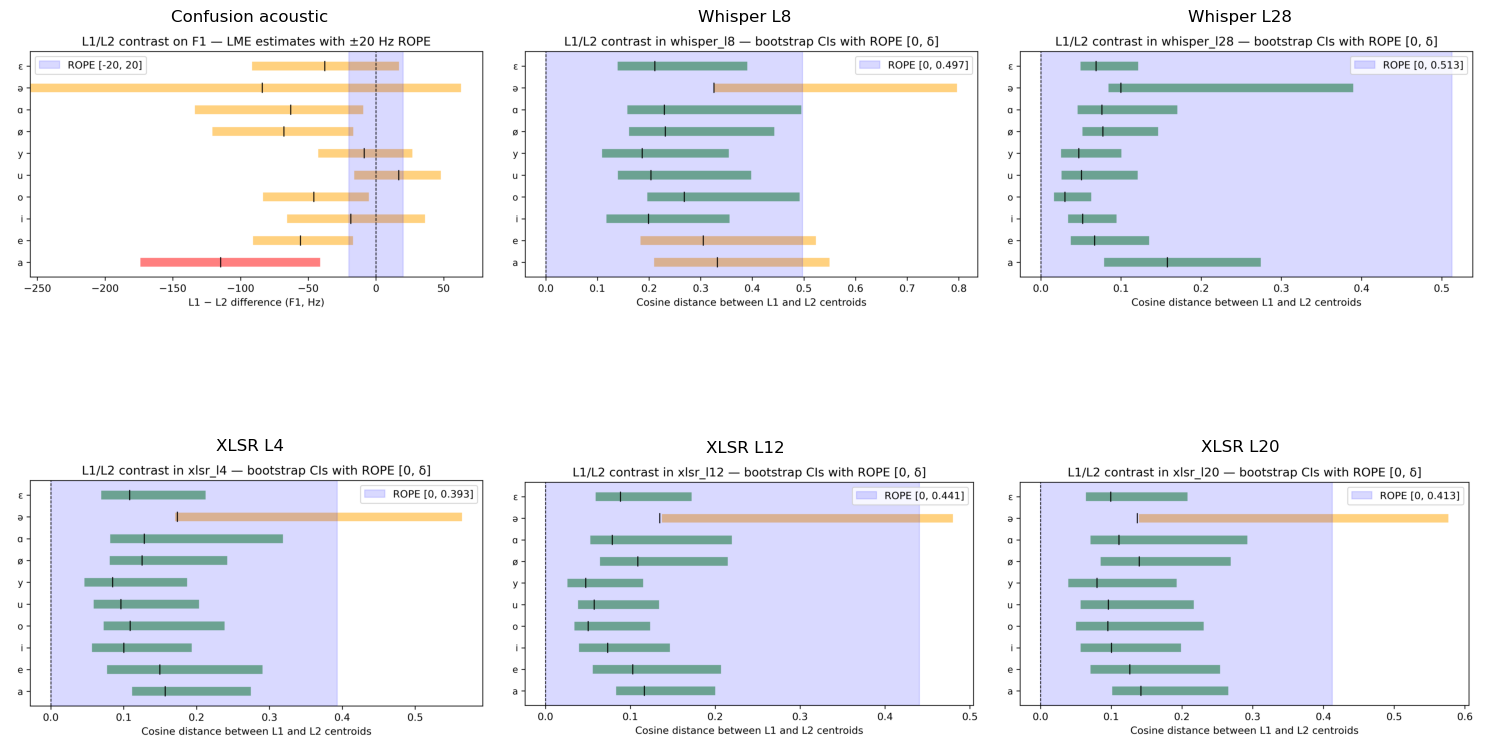

In [ ]:
imgs = [
    Image.open("../outputs/analysis/figures/8_forest_acoustic_F1_L1vsL2.png"),
    Image.open("../outputs/analysis/figures/8_forest_neural_whisper_l8.png"),
    Image.open("../outputs/analysis/figures/8_forest_neural_whisper_l28.png"),
    Image.open("../outputs/analysis/figures/8_forest_neural_xlsr_l4.png"),
    Image.open("../outputs/analysis/figures/8_forest_neural_xlsr_l12.png"),
    Image.open("../outputs/analysis/figures/8_forest_neural_xlsr_l20.png")
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Hierachical Clustering

In [13]:
TABLES = Path("../src/outputs/analysis/tables")
phon = pd.read_csv(TABLES / "9_clustering_phonemes.csv")
phon

,tag,metric,n_phonemes,best_k,silhouette_at_best_k,silhouette_curve,ari_front_back_k2,ari_high_mid_low_k3,ari_front_back_at_best_k,ari_high_mid_low_at_best_k,ari_consonant_vowel_k2
0,acoustic_vowels,euclidean,10,3,0.418808,"{2: 0.356, 3: 0.419, 4: 0.408, 5: 0.347, 6: 0....",0.414414,0.265506,0.392523,0.265506,NaN
1,whisper_l28_vowels,cosine,10,2,0.293651,"{2: 0.294, 3: 0.234, 4: 0.235, 5: 0.262, 6: 0....",-0.050420,0.629847,-0.050420,0.398931,NaN
2,whisper_l8_vowels,cosine,10,2,0.380328,"{2: 0.38, 3: 0.343, 4: 0.363, 5: 0.342, 6: 0.348}",0.122807,0.066820,0.122807,0.219653,NaN
3,xlsr_l12_vowels,cosine,10,2,0.376033,"{2: 0.376, 3: 0.327, 4: 0.326, 5: 0.343, 6: 0....",-0.050420,0.629847,-0.050420,0.398931,NaN
4,xlsr_l20_vowels,cosine,10,4,0.408396,"{2: 0.398, 3: 0.383, 4: 0.408, 5: 0.346, 6: 0....",-0.050420,0.265506,0.607843,0.136691,NaN
5,xlsr_l4_vowels,cosine,10,2,0.421199,"{2: 0.421, 3: 0.355, 4: 0.399, 5: 0.352, 6: 0....",0.122807,0.066820,0.122807,0.219653,NaN
6,acoustic_mixed,euclidean_zscored,10,2,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
7,whisper_l28_mixed,cosine,18,2,NaN,NaN,NaN,NaN,NaN,NaN,0.000339
8,whisper_l8_mixed,cosine,18,2,NaN,NaN,NaN,NaN,NaN,NaN,0.582822
9,xlsr_l12_mixed,cosine,18,2,NaN,NaN,NaN,NaN,NaN,NaN,0.582822


In [102]:
TABLES = Path("../src/outputs/analysis/tables")

phon = pd.read_csv(TABLES / "9_clustering_phonemes.csv")

vowels_table = phon[phon["tag"].str.endswith("_vowels")][[
    "tag",
    "best_k",
    "silhouette_at_best_k",
    "ari_front_back_k2",
    "ari_high_mid_low_k3",
    "ari_front_back_at_best_k",
]].copy()

vowels_table["tag"] = vowels_table["tag"].str.replace("_vowels", "")
vowels_table = vowels_table.rename(columns={"tag": "representation"})
vowels_table = vowels_table.round(3)

print("=== Table 14 - Vowel clustering ===")
vowels_table

=== Table 14 - Vowel clustering ===


,representation,best_k,silhouette_at_best_k,ari_front_back_k2,ari_high_mid_low_k3,ari_front_back_at_best_k
0,acoustic,3,0.419,0.414,0.266,0.393
1,whisper_l28,2,0.294,-0.050,0.630,-0.050
2,whisper_l8,2,0.380,0.123,0.067,0.123
3,xlsr_l12,2,0.376,-0.050,0.630,-0.050
4,xlsr_l20,4,0.408,-0.050,0.266,0.608
5,xlsr_l4,2,0.421,0.123,0.067,0.123


In [107]:
mixed_table = phon[phon["tag"].str.endswith("_mixed")][[
    "tag",
    "n_phonemes",
    "ari_consonant_vowel_k2",
]].copy()

mixed_table["tag"] = mixed_table["tag"].str.replace("_mixed", "")
mixed_table = mixed_table.rename(columns={"tag": "representation"})
mixed_table = mixed_table.round(3)

print("=== Table 15 - Consonant/vowel clustering ===")
mixed_table

=== Table 15 - Consonant/vowel clustering ===


,representation,n_phonemes,ari_consonant_vowel_k2
6,acoustic,10,0.000
7,whisper_l28,18,0.000
8,whisper_l8,18,0.583
9,xlsr_l12,18,0.583
10,xlsr_l20,18,0.583
11,xlsr_l4,18,0.583


In [108]:
spk = pd.read_csv(TABLES / "9_clustering_speakers.csv")

spk_pivot = spk.pivot_table(
    index="representation",
    columns="grouping",
    values="ari"
).round(3)

print("=== Table 16 - Speaker clustering ===")
spk_pivot

=== Table 16 - Speaker clustering ===


grouping,gender,l1_status
representation,,
acoustic,-0.016,-0.109
whisper_l28,-0.084,-0.141
whisper_l8,0.637,0.335
xlsr_l12,0.637,0.335
xlsr_l20,0.636,0.353
xlsr_l4,0.637,0.335


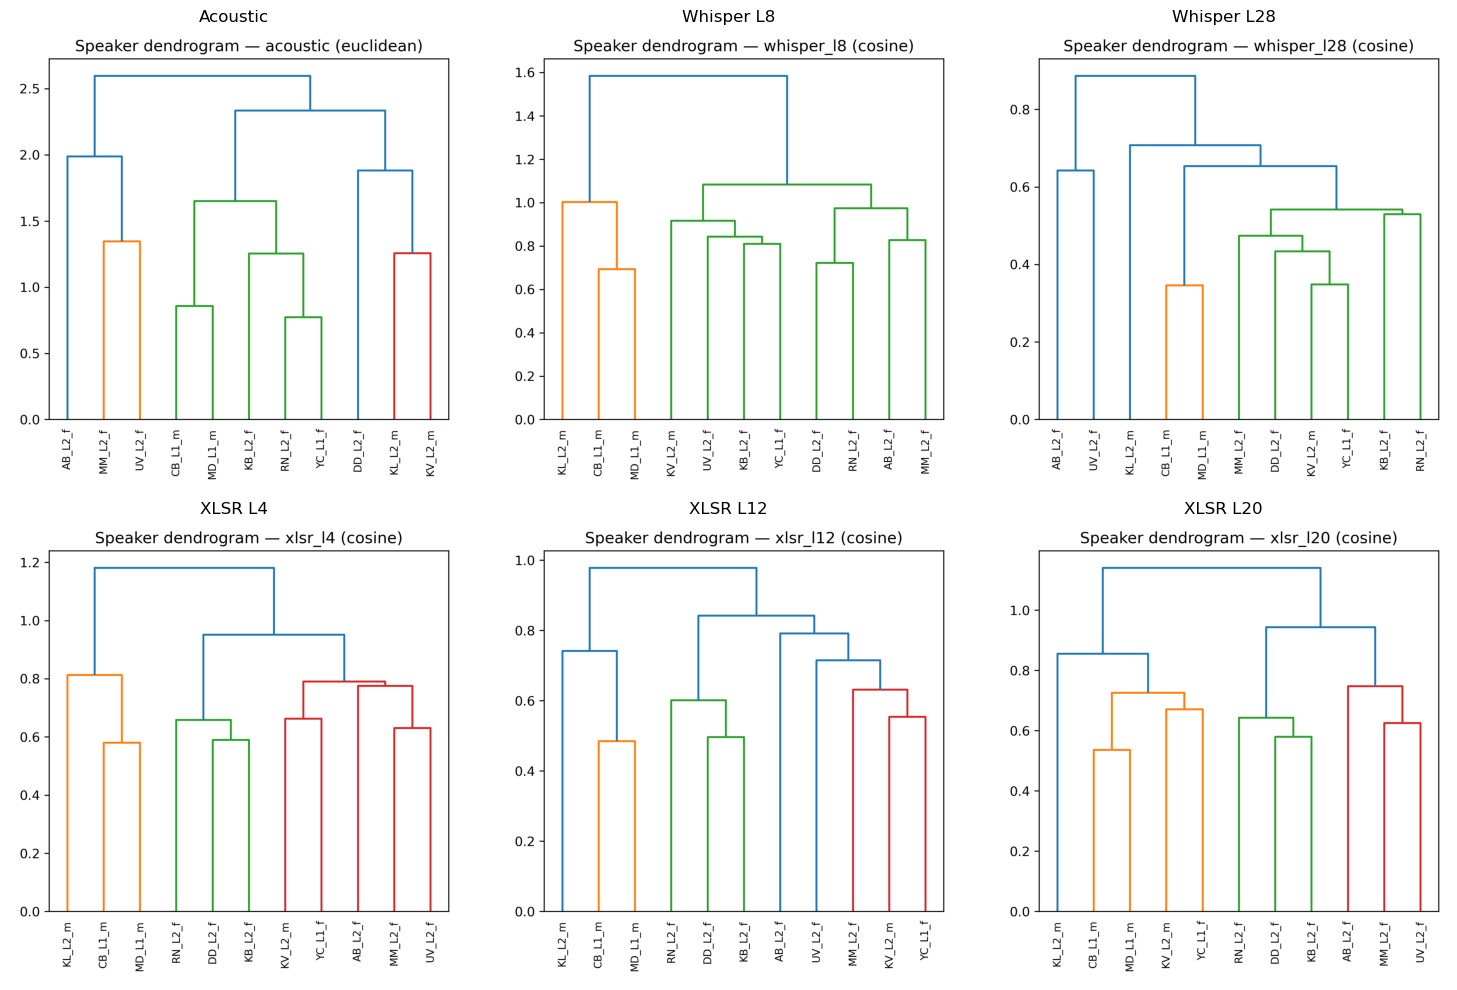

In [12]:
imgs = [
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_acoustic.png"),
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_whisper_l8.png"),
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_whisper_l28.png"),
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_xlsr_l4.png"),
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_xlsr_l12.png"),
    Image.open("../src/outputs/analysis/figures/9_3_speaker_dendro_xlsr_l20.png"),
]
titles = [
    "Acoustic",
    "Whisper L8",
    "Whisper L28",
    "XLSR L4",
    "XLSR L12",
    "XLSR L20"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(titles[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
df = pd.read_csv("../src/outputs/analysis/tables/9_clustering_speakers.csv")
df

,representation,metric,n_speakers,grouping,k,ari
0,acoustic,euclidean,11,l1_status,2,-0.108871
1,acoustic,euclidean,11,gender,2,-0.015831
2,whisper_l28,cosine,11,l1_status,2,-0.141079
3,whisper_l28,cosine,11,gender,2,-0.084100
4,whisper_l8,cosine,11,l1_status,2,0.334677
5,whisper_l8,cosine,11,gender,2,0.637203
6,xlsr_l12,cosine,11,l1_status,2,0.334677
7,xlsr_l12,cosine,11,gender,2,0.637203
8,xlsr_l20,cosine,11,l1_status,2,0.352941
9,xlsr_l20,cosine,11,gender,2,0.635762
